<h1>Подготовка обучающей и тестовой выборки, кросс-валидация и подбор гиперпараметров на примере метода ближайших соседей.</h1>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")
data = pd.read_csv('Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv', sep=",")

data.head(5)

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [2]:
print(data.isnull().sum())

data_cleaned = data.dropna(axis=1)

print(f"\nРазмер данных до очистки: {data.shape}")
print(f"Размер данных после очистки: {data_cleaned.shape}")

data = data_cleaned


transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

Размер данных до очистки: (7500, 16)
Размер данных после очистки: (7500, 15)


In [3]:
stress_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
data['stress_level_encoded'] = data['stress_level'].map(stress_mapping)

impact_mapping = {'No': 0, 'Yes': 1}
data['academic_work_impact_encoded'] = data['academic_work_impact'].map(impact_mapping)

data = data.drop(['stress_level', 'academic_work_impact'], axis=1)

print(data[['stress_level_encoded', 'academic_work_impact_encoded']].head())

   stress_level_encoded  academic_work_impact_encoded
0                     1                             1
1                     1                             1
2                     2                             0
3                     2                             1
4                     0                             0


In [4]:
from sklearn.model_selection import train_test_split

data_cleaned = data.drop(["transaction_id", "user_id", "gender"], axis=1)

train_data, test_data = train_test_split(data_cleaned, test_size=0.3, random_state=42)

print(f"Размер обучающей выборки: {train_data.shape}")
print(f"Размер тестовой выборки: {test_data.shape}")

Размер обучающей выборки: (5250, 12)
Размер тестовой выборки: (2250, 12)


In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

X_train = train_data.drop(['addicted_label'], axis=1)
y_train = train_data['addicted_label']
X_test = test_data.drop(['addicted_label'], axis=1)
y_test = test_data['addicted_label']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k = 5

knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred, average='weighted'):.4f}")

print("\nМатрица ошибок:")
print(confusion_matrix(y_test, y_pred))

print("\nДетальный отчет по классам:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8831
Precision: 0.8819
Recall: 0.8831
F1-score: 0.8823

Матрица ошибок:
[[ 526  147]
 [ 116 1461]]

Детальный отчет по классам:
              precision    recall  f1-score   support

           0       0.82      0.78      0.80       673
           1       0.91      0.93      0.92      1577

    accuracy                           0.88      2250
   macro avg       0.86      0.85      0.86      2250
weighted avg       0.88      0.88      0.88      2250



Fitting 5 folds for each of 30 candidates, totalling 150 fits


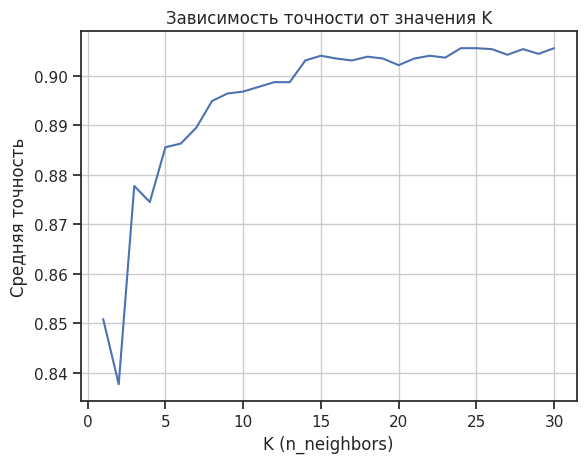

Лучшие параметры (GridSearchCV): {'n_neighbors': 25}
Лучшая кросс-валидационная оценка: 0.9055
Точность на тестовых данных: 0.8996
Fitting 5 folds for each of 30 candidates, totalling 150 fits


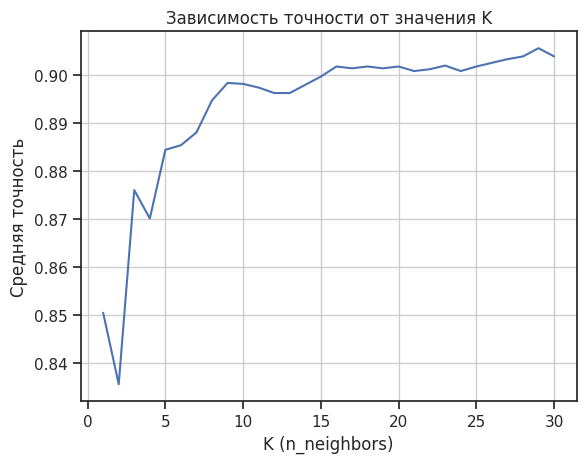

Лучшие параметры (RandomizedSearchCV): {'n_neighbors': 29}
Лучшая кросс-валидационная оценка: 0.9055
Точность на тестовых данных: 0.9009
Тестовая точность (GridSearchCV): 0.8996
Тестовая точность (RandomizedSearchCV): 0.9009


In [22]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold, StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier

# 1. GridSearchCV с K-Fold кросс-валидацией
knn_grid = KNeighborsClassifier()
param_grid = {
    'n_neighbors': list(range(1, 31))
}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=knn_grid,
    param_grid=param_grid,
    cv=kfold,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)
plt.plot(range(1,31), grid_search.cv_results_['mean_test_score'])
plt.xlabel('K (n_neighbors)')
plt.ylabel('Средняя точность')
plt.title('Зависимость точности от значения K')
plt.grid(True)
plt.show()

print(f"Лучшие параметры (GridSearchCV): {grid_search.best_params_}")
print(f"Лучшая кросс-валидационная оценка: {grid_search.best_score_:.4f}")
print(f"Точность на тестовых данных: {grid_search.score(X_test_scaled, y_test):.4f}")

# 2. RandomizedSearchCV со Stratified K-Fold кросс-валидацией
knn_random = KNeighborsClassifier()
param_dist = {
    'n_neighbors': list(range(1, 31))
}

stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=knn_random,
    param_distributions=param_dist,
    n_iter=30,
    cv=stratified_kfold,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train_scaled, y_train)

plt.plot(range(1,31), random_search.cv_results_['mean_test_score'])
plt.xlabel('K (n_neighbors)')
plt.ylabel('Средняя точность')
plt.title('Зависимость точности от значения K')
plt.grid(True)
plt.show()

print(f"Лучшие параметры (RandomizedSearchCV): {random_search.best_params_}")
print(f"Лучшая кросс-валидационная оценка: {random_search.best_score_:.4f}")
print(f"Точность на тестовых данных: {random_search.score(X_test_scaled, y_test):.4f}")

# 3. Сравнение различных стратегий кросс-валидации
best_knn = KNeighborsClassifier(**grid_search.best_params_)

final_knn_grid = KNeighborsClassifier(**grid_search.best_params_)
final_knn_grid.fit(X_train_scaled, y_train)

final_knn_random = KNeighborsClassifier(**random_search.best_params_)
final_knn_random.fit(X_train_scaled, y_train)

grid_test_score = final_knn_grid.score(X_test_scaled, y_test)
random_test_score = final_knn_random.score(X_test_scaled, y_test)

print(f"Тестовая точность (GridSearchCV): {grid_test_score:.4f}")
print(f"Тестовая точность (RandomizedSearchCV): {random_test_score:.4f}")

In [24]:
knn_initial = KNeighborsClassifier(n_neighbors=5)
knn_initial.fit(X_train_scaled, y_train)
y_pred_initial = knn_initial.predict(X_test_scaled)

knn_optimal = KNeighborsClassifier(n_neighbors=29)
knn_optimal.fit(X_train_scaled, y_train)
y_pred_optimal = knn_optimal.predict(X_test_scaled)

print("\n{:<25} {:>15} {:>15} {:>10}".format("Метрика", "Исходная", "Оптимальная", "Разница"))
print("-" * 70)

accuracy_initial = accuracy_score(y_test, y_pred_initial)
accuracy_optimal = accuracy_score(y_test, y_pred_optimal)
print("{:<25} {:>15.4f} {:>15.4f} {:>+10.4f}".format(
    "Accuracy", accuracy_initial, accuracy_optimal, accuracy_optimal - accuracy_initial))

precision_initial = precision_score(y_test, y_pred_initial, average='weighted')
precision_optimal = precision_score(y_test, y_pred_optimal, average='weighted')
print("{:<25} {:>15.4f} {:>15.4f} {:>+10.4f}".format(
    "Precision", precision_initial, precision_optimal, precision_optimal - precision_initial))

recall_initial = recall_score(y_test, y_pred_initial, average='weighted')
recall_optimal = recall_score(y_test, y_pred_optimal, average='weighted')
print("{:<25} {:>15.4f} {:>15.4f} {:>+10.4f}".format(
    "Recall", recall_initial, recall_optimal, recall_optimal - recall_initial))

f1_initial = f1_score(y_test, y_pred_initial, average='weighted')
f1_optimal = f1_score(y_test, y_pred_optimal, average='weighted')
print("{:<25} {:>15.4f} {:>15.4f} {:>+10.4f}".format(
    "F1-score", f1_initial, f1_optimal, f1_optimal - f1_initial))



Метрика                          Исходная     Оптимальная    Разница
----------------------------------------------------------------------
Accuracy                           0.8831          0.9009    +0.0178
Precision                          0.8819          0.8998    +0.0179
Recall                             0.8831          0.9009    +0.0178
F1-score                           0.8823          0.9001    +0.0178
